# Import packages

In [1]:
# Define project path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

In [2]:
# Import python packages
import pandas as pd
import matplotlib.pyplot as plt

# Import functions from custom package ntcp_fit
from ntcp_fit.config import define_settings
from ntcp_fit.optimization import fit_model
from ntcp_fit.goodness_of_fit import calibration_plot, auc_plot
from ntcp_fit.bootstrap import fit_bootstrap

# Import Data

In [3]:
# Import synthetic data
DATA_DIR = PROJECT_ROOT / "data"

data_path = DATA_DIR / "synth_data_1000pts.xlsx"

data = pd.read_excel(data_path)

In [4]:
# Define the model settings by specifying the SNP columns to include in each model.
# See `help(define_settings)` for a complete description of all available settings.
define_settings(SNPs_U = ["SNP_1", "SNP_2"], SNPs_I=["SNP_3", "SNP_4"])

# help(define_settings)

# Fit model

In [5]:
# Fit the combined-endpoint model and store the results
fit_res = fit_model(data)

Parameter               Estimate
--------------------------------
beta_0_U                -3.72881
beta_EUDb                0.00280
beta_EUDb_ATM            0.16038
beta_EUDb_PRS            0.73161
beta_PRS_U               0.02608
beta_0_PRS_U            -0.78553
beta_0_I                -3.31776
beta_EUDr                0.01073
beta_EUDr_ATM            0.10206
beta_EUDr_PRS            0.58278
beta_PRS_I               0.00091
beta_0_PRS_I            -0.92279
SNP_1(U)                 0.12814
SNP_2(U)                -0.05793
SNP_3(I)                 0.03573
SNP_4(I)                 0.06414

NLL_UI_tot            1228.79727
NLL_UI                 647.75689
NLL_U                  571.44160
NLL_I                  590.63917
NLL_UI_no_pen         1228.79727
pen_L1 (L1 = 0)          0.00000
pen_L2 (L2 = 0)          0.00000
pen_J (LJ = 0.5)       581.04039
opt_success                 True


# Classification

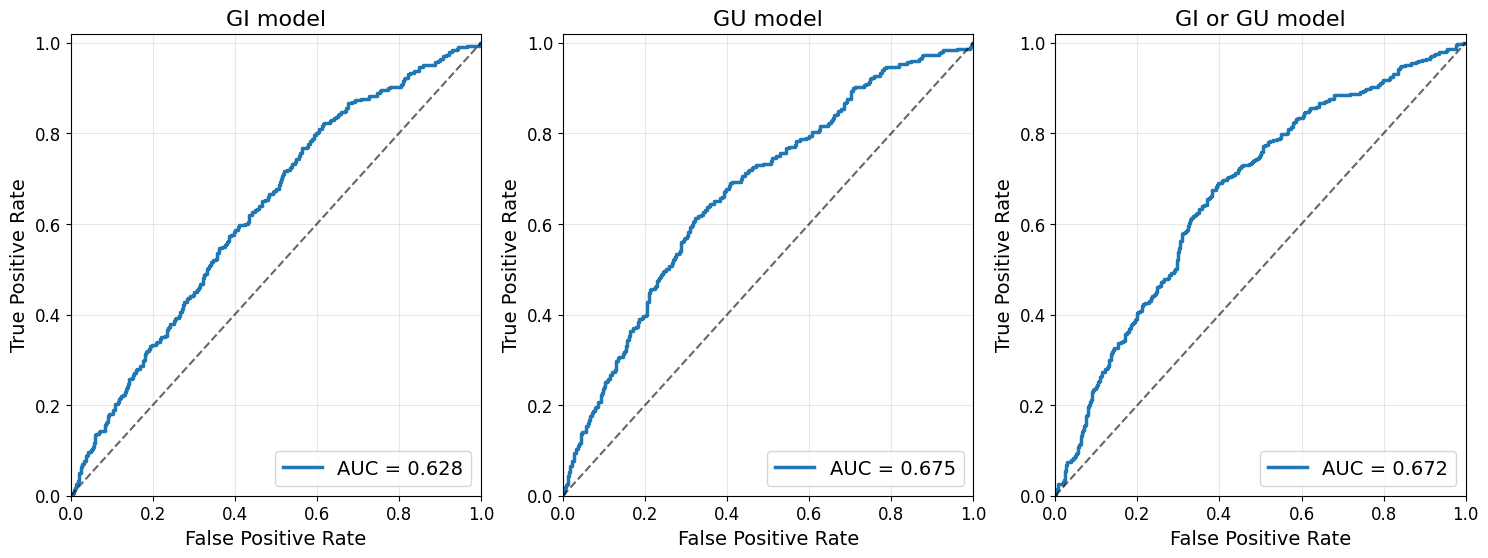

In [6]:
# Plot the classification performance of the combined model for each endpoint:
# urinary toxicity, intestinal toxicity, and the combined endpoint (U or I).

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
auc_plot(data['outcome_I'], fit_res['predictions_I'], title=f'GI model', ax=axes[0])  # I endpoint
auc_plot(data['outcome_U'], fit_res['predictions_U'], title=f'GU model', ax=axes[1])  # U endpoint
auc_plot(data['outcome'], fit_res['predictions_overall'], title=f'GI or GU model', ax=axes[2]) # I or U endpoint (combined)
plt.show()

# Calibration

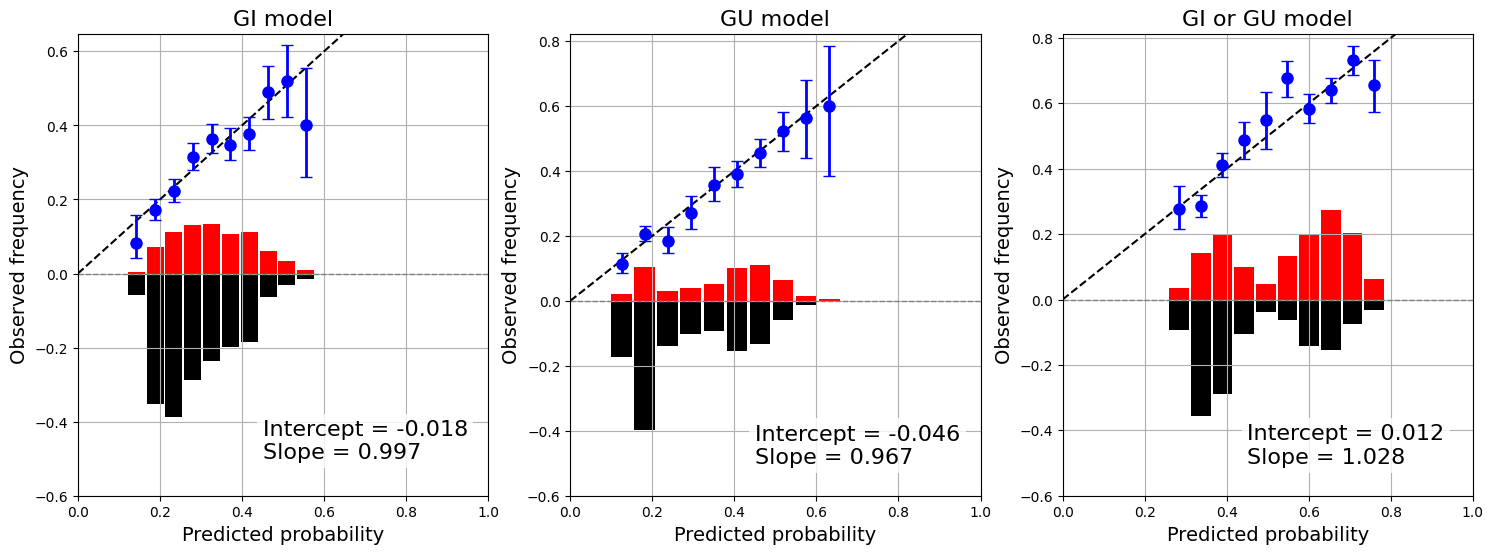

In [7]:
# Plot the calibration performance of the combined model for each endpoint:
# urinary toxicity, intestinal toxicity, and the combined endpoint (U or I).

n_bins = 10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
calibration_plot(data['outcome_I'], fit_res['predictions_I'], n_bins = n_bins, title=f'GI model', ax=axes[0])
calibration_plot(data['outcome_U'], fit_res['predictions_U'], n_bins = n_bins, title=f'GU model', ax=axes[1])
calibration_plot(data['outcome'], fit_res['predictions_overall'], n_bins = n_bins, title=f'GI or GU model', ax=axes[2])
plt.show()

# Bootstrap

In [8]:
# Estimate parameter uncertainty using constrained bootstrap resampling
bootstrap_res = fit_bootstrap(data, N_bootstraps = 500, coverage = 0.9)

Generating bootstrap samples...
Fitting bootstrap samples...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed: 10.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 13.4min finished





Parameter                      Estimate [90% CI]
------------------------------------------------------------
beta_0_U                   -3.729 [-9.652, -3.033]
beta_EUDb                   0.003 [0.000, 0.110]
beta_EUDb_ATM               0.160 [0.141, 0.185]
beta_EUDb_PRS               0.732 [-4.130, 1.858]
beta_PRS_U                  0.026 [0.000, 38.209]
beta_0_PRS_U               -0.786 [-1.895, -0.331]
beta_0_I                   -3.318 [-4.973, -2.818]
beta_EUDr                   0.011 [0.000, 0.035]
beta_EUDr_ATM               0.102 [0.081, 0.122]
beta_EUDr_PRS               0.583 [-0.697, 1.083]
beta_PRS_I                  0.001 [0.000, 10.458]
beta_0_PRS_I               -0.923 [-1.084, -0.697]
SNP_1(U)                    0.128 [-0.216, 0.288]
SNP_2(U)                   -0.058 [-0.451, 0.006]
SNP_3(I)                    0.036 [-0.081, 0.186]
SNP_4(I)                    0.064 [-0.040, 0.170]
NLL_UI_tot               1228.797 [1216.711, 1243.105]
NLL_I                     590.63